# 🎬 The Popularity Paradox
## Why the Most Viewed YouTube Categories Aren't the Most Appreciated

---

> *"A video with 500 million views sounds like a clear success. But does that really mean people loved it?"*

**Dataset:** YouTube Trending — Kaggle (161,470 trending videos) 
**Metric created:** `like_ratio` = likes ÷ views 
**Tools:** Python · Pandas · Matplotlib · Seaborn 
**Challenge:** Codédex February 2026 Dataset Challenge

---
## 📖 The Story

Ever since I can remember, YouTube has been part of my life. It was one of the first platforms I discovered, and I loved watching YouTubers, summaries, and series. But as I grew older, I started noticing something strange.

Sometimes, a video I genuinely enjoyed had relatively few views. Meanwhile, another video that didn’t seem interesting at all had millions. That always made me wonder: why?

Think about it — how many times have you clicked on a video, watched fifteen seconds, and left? That still counts as a view. A catchy thumbnail, a trending topic, or the algorithm pushing content can generate millions of views — even if people don’t truly enjoy what they’re watching.

So when I chose a dataset for this challenge, one question kept coming back to me:

On YouTube, does popularity really mean appreciation?

To explore this, I used the YouTube Trending dataset from Kaggle, which includes 161,470 trending videos across multiple countries and 15 categories. Instead of focusing only on views, I created a new metric called like_ratio — measuring how many viewers actually pressed the “like” button compared to how many watched the video.

That small shift — from counting clicks to measuring appreciation — completely changed the way I looked at YouTube categories.

And what I found was not what I expected.

---
## STEP 1 — Load the Libraries and the Dataset

First, we load the tools and read the CSV into Python.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visual style
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

# Load dataset
df = pd.read_csv('youtube.csv')

print(f'Dataset loaded: {df.shape[0]:,} rows and {df.shape[1]} columns')
df.head()

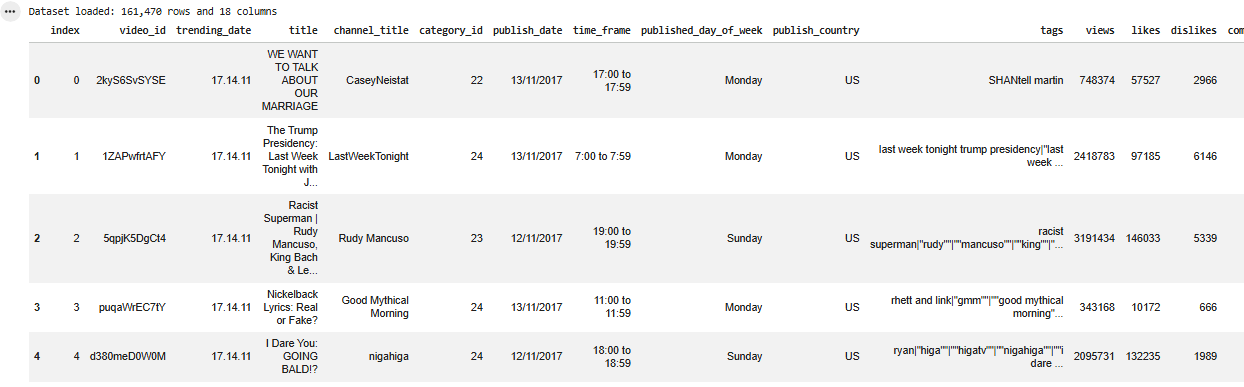

---
## STEP 2 — Explore the Data

Before jumping to any conclusions, I took a look at the structure of the dataset to understand what I was working with.

In [ ]:
df.info()

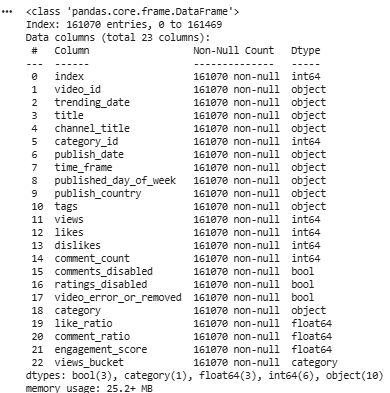

The dataset has **161,470 rows** and **18 columns**. All key columns — views, likes, category_id — are complete. No major cleaning needed. Good to go.

---
## STEP 3 — Assign Category IDs to Real Names

The dataset stores categories as numbers (1, 10, 20...). These are the official YouTube IDs. Because the CVS dataset doesn't include the names, and I found out that these IDs are official and used by the YouTube platform, I assigned them to real names so the charts would be readable.

In [ ]:
category_map = {
    1:  'Film & Animation',
    2:  'Autos & Vehicles',
    10: 'Music',
    15: 'Pets & Animals',
    17: 'Sports',
    19: 'Travel & Events',
    20: 'Gaming',
    22: 'People & Blogs',
    23: 'Comedy',
    24: 'Entertainment',
    25: 'News & Politics',
    26: 'Howto & Style',
    27: 'Education',
    28: 'Science & Technology',
    29: 'Nonprofits & Activism'
}

df['category'] = df['category_id'].map(category_map)
df = df.dropna(subset=['category'])

print('Categories mapped successfully!')
print()
print('Videos per category:')
print(df['category'].value_counts())

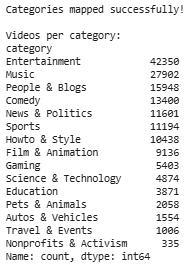

---
## STEP 4 — Create Engagement Metrics

This is the core of the project. Instead of just using raw view counts, I created three metrics that measure how people actually responded to videos:

- **`like_ratio`** → Out of every 100 viewers, how many liked the video?
- **`comment_ratio`** → Out of every 100 viewers, how many left a comment?
- **`engagement_score`** → Both combined, for a fuller picture of audience behavior

In [ ]:
df['like_ratio']        = df['likes'] / df['views']
df['comment_ratio']     = df['comment_count'] / df['views']
df['engagement_score']  = df['like_ratio'] + df['comment_ratio']

# Remove extreme outliers
df = df[df['views'] > 1000]
df = df[df['like_ratio'] <= 1]

print('Metrics created!')
print()
df[['views', 'like_ratio', 'comment_ratio']].describe().round(4)

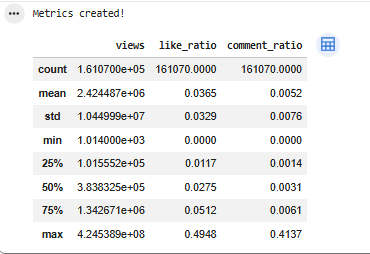

---
## STEP 5 — Build the Summary Table

Now I grouped everything by category and calculated the averages. This table is the foundation for all the charts and findings below.

In [ ]:
summary = df.groupby('category').agg(
    avg_views         = ('views', 'mean'),
    avg_like_ratio    = ('like_ratio', 'mean'),
    avg_comment_ratio = ('comment_ratio', 'mean'),
    total_videos      = ('video_id', 'count')
).sort_values('avg_views', ascending=False).round(4)

print('Summary table ready!')
summary

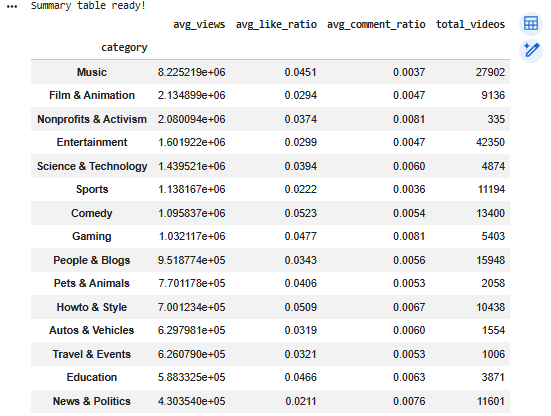

---
## 📊 Finding 1 — The Rankings Flip Completely

Before I even made a chart, I looked at this table and something immediately stood out.

**Music** is the clear winner in views — averaging over 8.2 million views per trending video. But its like ratio? 4.51%. That's not bad, but it puts Music at **5th place** for appreciation, not 1st.

**Comedy**, which doesn't even crack the top 5 in views, leads in like ratio at 5.23%. **Howto & Style** is 2nd in appreciation with 5.09%, while sitting near the bottom for views.

The categories that dominate clicks are not the ones that earn the most love. Let's see that visually.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('The Popularity Paradox on YouTube', fontsize=20, fontweight='bold', y=1.01)

# LEFT: Average Views
views_sorted = summary['avg_views'].sort_values(ascending=True)
colors_v = ['#FF6B6B' if v == views_sorted.max() else '#4ECDC4' for v in views_sorted]
axes[0].barh(views_sorted.index, views_sorted.values / 1e6, color=colors_v, edgecolor='white', linewidth=0.5)
axes[0].set_title('Most Viewed Categories\n(Average Views per Video)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Views (Millions)', fontsize=11)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_facecolor('#f9f9f9')

# RIGHT: Like Ratio
engage_sorted = summary['avg_like_ratio'].sort_values(ascending=True)
colors_e = ['#FF6B6B' if v == engage_sorted.max() else '#A29BFE' for v in engage_sorted]
axes[1].barh(engage_sorted.index, engage_sorted.values * 100, color=colors_e, edgecolor='white', linewidth=0.5)
axes[1].set_title('Most Appreciated Categories\n(Like Ratio %)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Like Ratio (%)', fontsize=11)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('chart1_views_vs_engagement.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart 1 saved.')

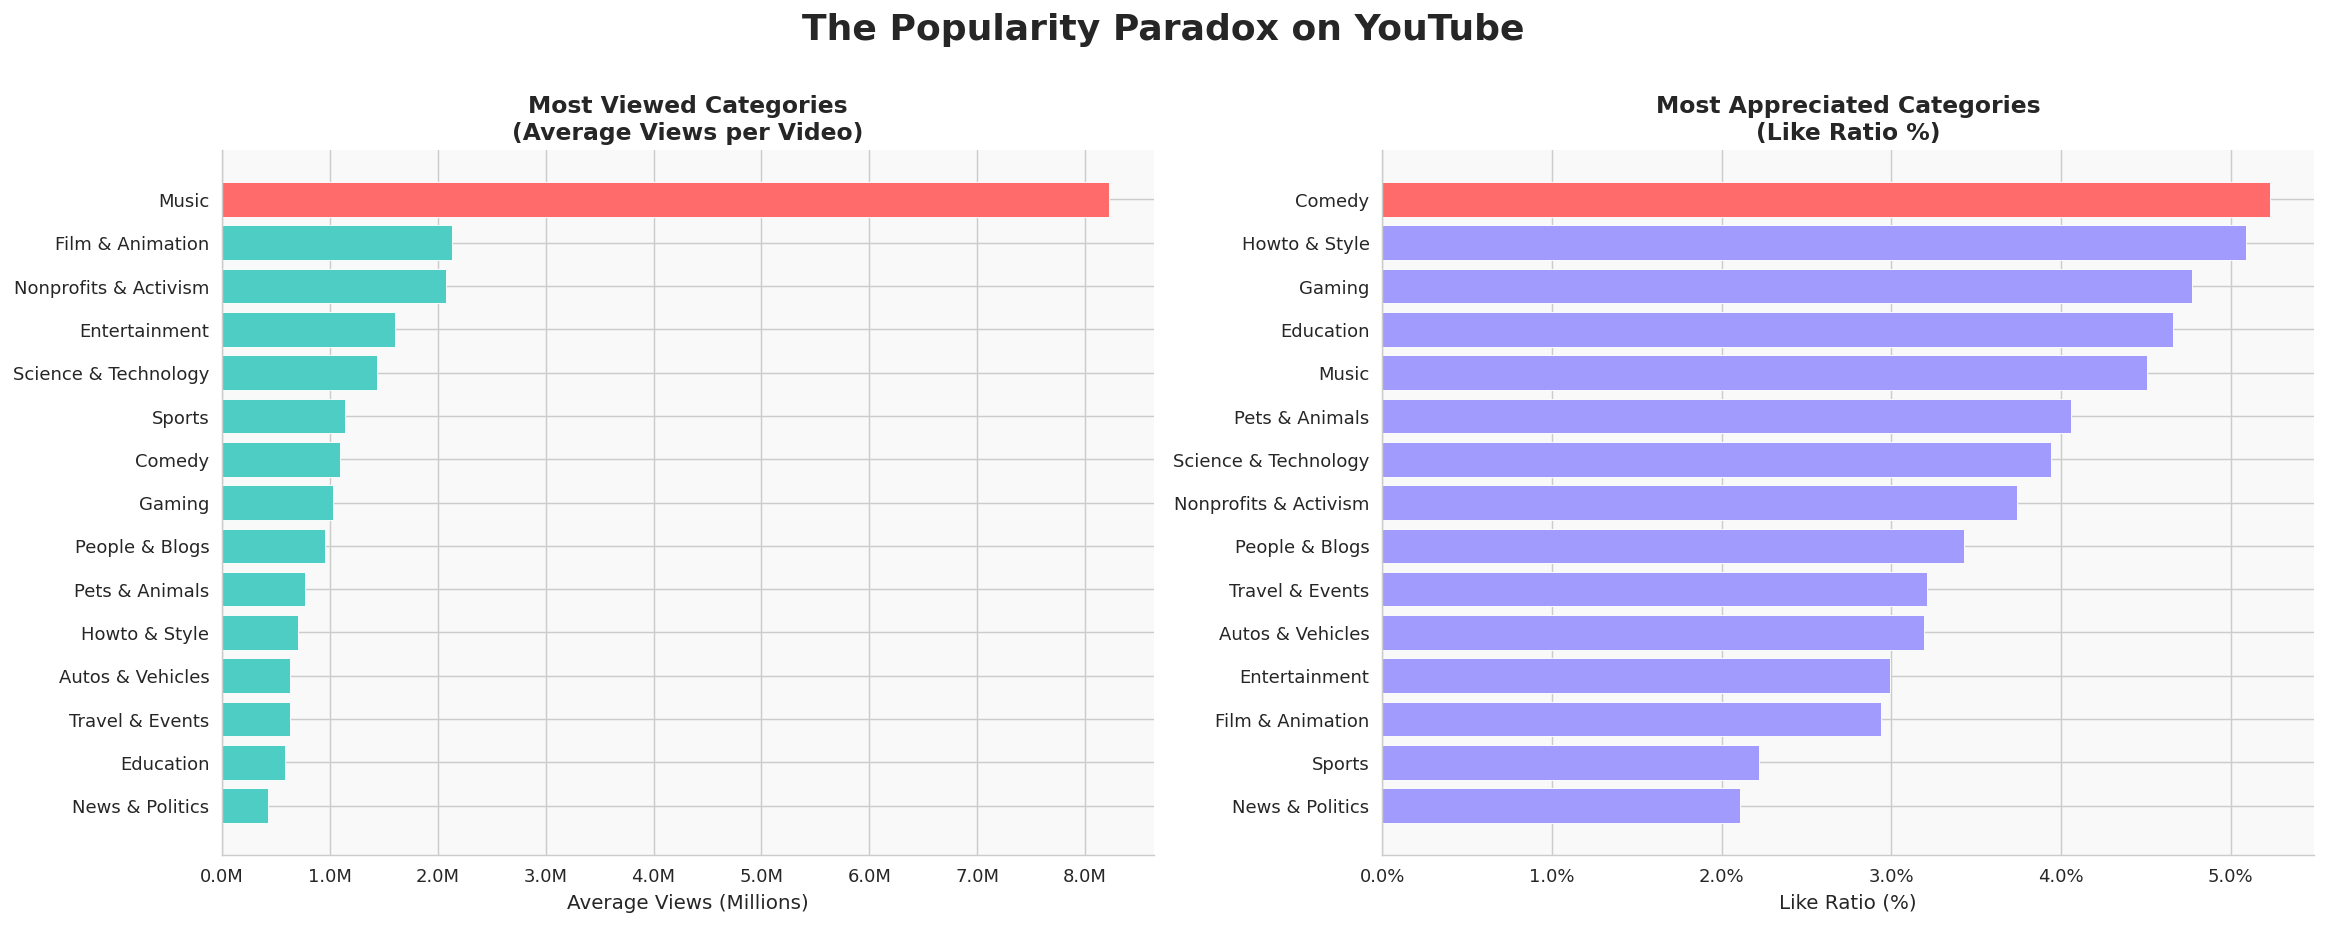

**What this shows:** Music dominates on the left — but Comedy and Howto & Style lead on the right. The rankings flip completely. That's the paradox in its simplest form.

---
### CHART 2 — Scatter Plot: Where Do Categories Actually Land?

Each bubble is a category. Bigger bubble = more trending videos in that category. If popularity and appreciation were correlated, all bubbles would align diagonally from bottom-left to top-right. They don't.

In [ ]:
fig, ax = plt.subplots(figsize=(13, 8))

scatter = ax.scatter(
    summary['avg_views'] / 1e6,
    summary['avg_like_ratio'] * 100,
    s=summary['total_videos'] / 8,
    alpha=0.78,
    c=summary['avg_like_ratio'],
    cmap='RdYlGn',
    edgecolors='gray',
    linewidth=0.6
)

for cat, row in summary.iterrows():
    ax.annotate(
        cat,
        xy=(row['avg_views'] / 1e6, row['avg_like_ratio'] * 100),
        fontsize=8.5, ha='left', va='bottom',
        xytext=(5, 4), textcoords='offset points'
    )

ax.set_xlabel('Average Views per Video (Millions)', fontsize=12)
ax.set_ylabel('Average Like Ratio (%)', fontsize=12)
ax.set_title('Views vs. Appreciation — Does Popularity Equal Engagement?\n(Bubble size = number of trending videos in that category)', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('#f9f9f9')

plt.colorbar(scatter, ax=ax, label='Like Ratio')
plt.tight_layout()
plt.savefig('chart2_scatter_views_vs_likeratio.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart 2 saved.')

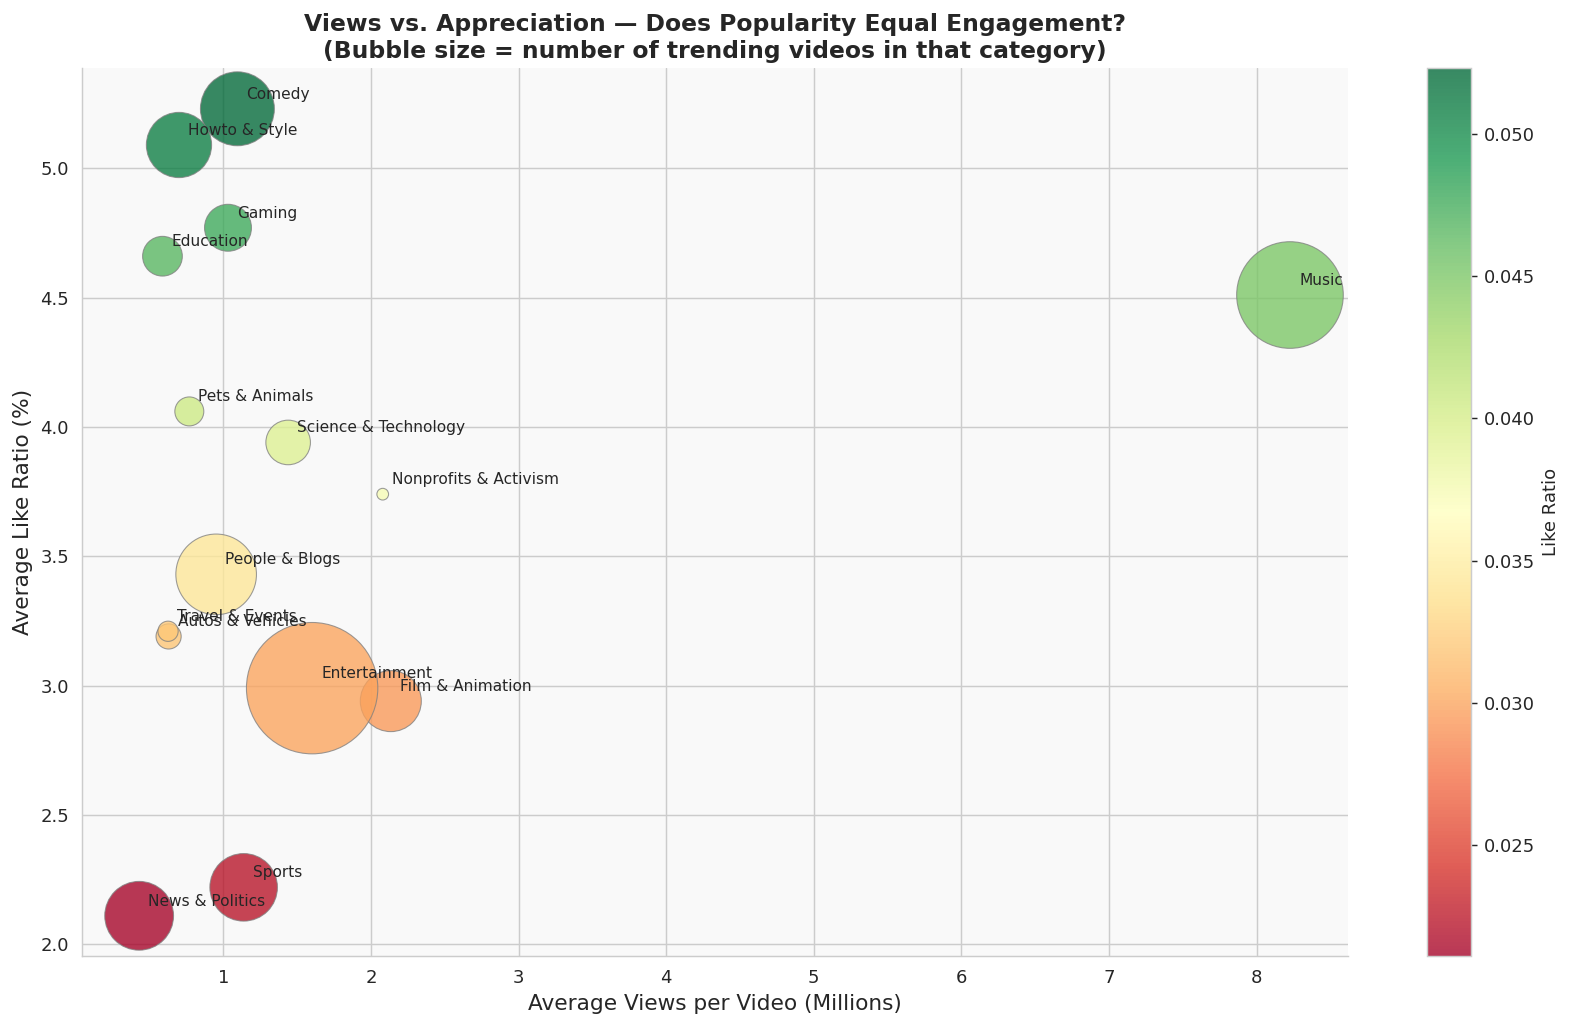

**What this shows:** Music sits far to the right (massive views) but isn't the highest on the Y axis. Comedy and Howto & Style sit to the left but near the top. No diagonal pattern — no correlation between views and appreciation.

---
## 🔍 Finding 2 — The Viral Paradox (The Sherlock Moment)

This is the part that surprised me most.

I had a theory: if the most-viewed *categories* don't always earn the most appreciation, what about the most-viewed *individual videos*? Do videos with 100 million+ views get more or less love per viewer than smaller videos?

I grouped every video into buckets by view count and measured the average like ratio for each bucket. The result was pretty striking.

### CHART 3 — The Viral Paradox: Do Mega-Viral Videos Get Less Love?

In [ ]:
df['views_bucket'] = pd.cut(
    df['views'],
    bins=[0, 1e5, 1e6, 10e6, 100e6, float('inf')],
    labels=['Under 100K', '100K – 1M', '1M – 10M', '10M – 100M', 'Over 100M']
)

viral_analysis = df.groupby('views_bucket', observed=True)['like_ratio'].mean() * 100

fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = ['#74b9ff', '#0984e3', '#fdcb6e', '#e17055', '#d63031']
bars = ax.bar(viral_analysis.index, viral_analysis.values, color=bar_colors, edgecolor='white', linewidth=0.8)

ax.set_title('The Viral Paradox: Do Mega-Viral Videos Get Less Love?\n(Average Like Ratio by View Count Range)', fontsize=13, fontweight='bold')
ax.set_xlabel('View Count Range', fontsize=11)
ax.set_ylabel('Average Like Ratio (%)', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('#f9f9f9')

for bar, val in zip(bars, viral_analysis.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_viral_paradox.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart 3 saved.')

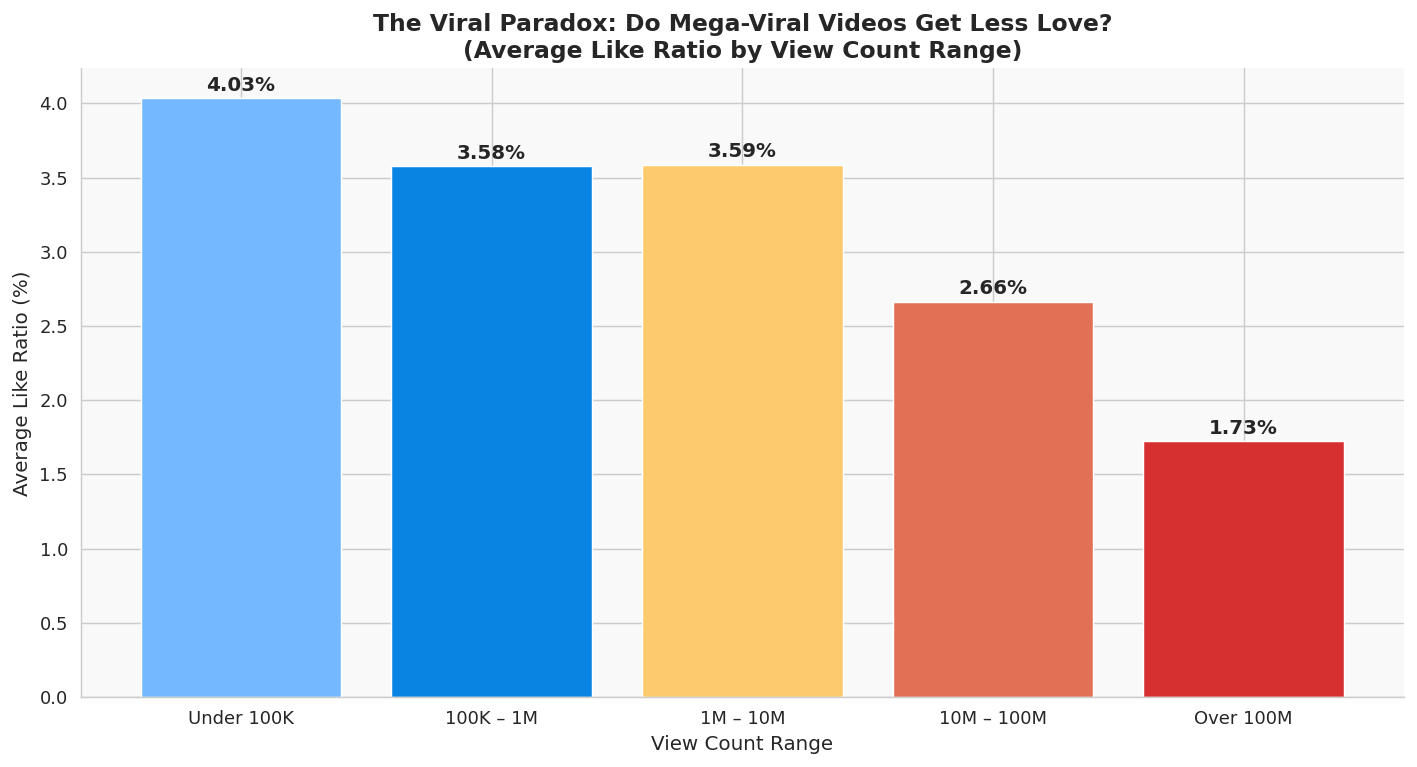

**The result:**

| View Range | Like Ratio | What it means |
|---|---|---|
| Under 100K | **4.03%** | Small but loyal audiences |
| 100K – 1M | 3.58% | Growing reach |
| 1M – 10M | 3.59% | The sweet spot |
| 10M – 100M | 2.66% | Big drop |
| **Over 100M** | **1.73%** | Mega-viral = less love |

**Videos with over 100M views have a like ratio 57% lower than videos under 100K.**

Going massively viral doesn't earn more appreciation — it correlates with less of it. When the algorithm pushes a video far beyond its natural audience, most of those extra viewers weren't really the target. They clicked, felt nothing, and left.

---
## 📊 Finding 3 — The Full Picture: Engagement Heatmap

Finally, I wanted to see all three metrics at once across all categories. A heatmap lets you compare everything side by side — darker means higher value. This is where you really see which categories dominate, which underperform, and where the biggest gaps are.

In [ ]:
heatmap_data = summary[['avg_views', 'avg_like_ratio', 'avg_comment_ratio']].copy()
heatmap_data.columns = ['Avg Views', 'Like Ratio', 'Comment Ratio']

# Normalize to 0-1 scale for fair comparison
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(
    heatmap_norm,
    annot=heatmap_data.round(4),
    fmt='',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Normalized Score (0 = lowest, 1 = highest)'}
)
ax.set_title('Engagement Heatmap by YouTube Category\n(Normalized for fair comparison across all metrics)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart 4 saved.')

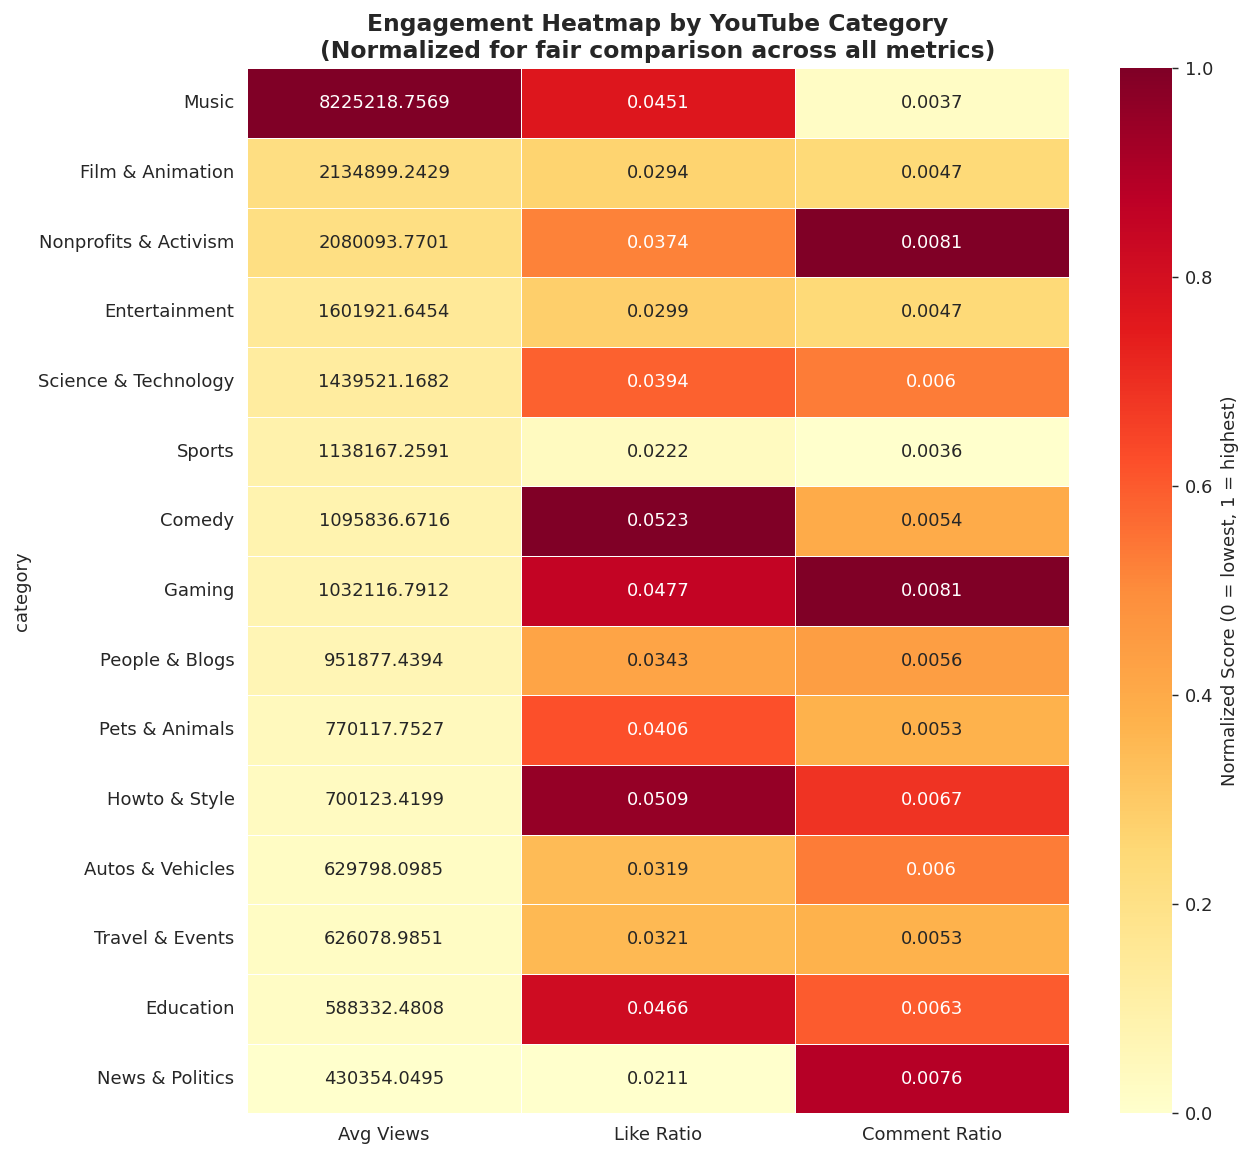

**What this shows:** Music dominates the Avg Views column completely — but in Like Ratio and Comment Ratio, Gaming, Comedy, Education and Howto & Style are the real winners. Niche communities engage harder. They show up because they want to, not because the algorithm pushed something in front of them.

---
## 🏁 Conclusions — What the Data Actually Tells Us

After going through 161,470 trending videos across 15 categories, three things became clear:

---

**Finding 1 — The most viewed categories are not the most appreciated.**
Music and Entertainment pull in massive view counts, but their like ratios don't match that reach. Comedy (5.23%) and Howto & Style (5.09%) earn the strongest proportional engagement, despite sitting far lower in total views. The rankings flip completely when you measure appreciation instead of reach.

---

**Finding 2 — Going viral doesn't mean people loved what they watched.**
Videos with over 100 million views show a like ratio 57% lower than videos under 100K views. When the algorithm sends a video far beyond its natural audience, those extra viewers weren't really the target — they clicked, felt nothing, and left. Going viral means more people saw it, not that more people cared.

---

**Finding 3 — Niche communities punch above their weight.**
Smaller, more focused categories consistently showed higher engagement per viewer. Gaming, Education, and Comedy audiences are more loyal, more active, and more likely to express genuine appreciation. Fewer total views — but a much higher share of people who actually liked what they saw.

---

### The Takeaway

> **On YouTube, popularity is loud. Appreciation is honest.**

If a creator's goal is to build a genuinely loyal audience, chasing raw view counts might be exactly the wrong strategy. The data suggests that resonating deeply with a smaller group consistently outperforms going viral with a larger one.

The most popular videos aren't the most loved. The most loved videos aren't the most popular. That's the paradox — and now we have 161,470 data points to prove it.

---
*Dataset: YouTube Trending — Kaggle | Tools: Python, Pandas, Matplotlib, Seaborn | Challenge: Codédex February 2026*


## Important Note on Interpretation (Correlation vs Causation)

As view counts increase, the average like ratio tends to decrease.  
This indicates a negative relationship between exposure scale and proportional appreciation —  
but it does **not** imply causation.

This analysis observes patterns in the data. It does not prove that virality causes lower appreciation.



## Limitations

This analysis is based exclusively on YouTube trending videos.  
The dataset does not represent all videos on YouTube — only those already boosted by the platform’s algorithm.

Trending content may behave differently from regular content, since it has already been selected for visibility.  
Therefore, these findings reflect patterns within trending videos, not the entire YouTube ecosystem.

Additionally, engagement metrics such as likes and comments may be influenced by audience behavior, cultural differences, or algorithmic exposure — factors not directly measured in this analysis.

Because of this, the results demonstrate correlation, not causation.



## Final Conclusion (Revised)

At first glance, popularity on YouTube seems simple: more views mean more success.

But this analysis reveals something more nuanced.

When measuring appreciation through like ratio instead of raw views, the rankings shift significantly.  
Categories that dominate in visibility are not always the ones that receive the highest proportional engagement.

Even more striking, videos with over 100 million views show significantly lower average like ratios compared to smaller videos.  
As exposure increases, appreciation — measured proportionally — tends to decrease.

This does not mean that virality causes lower appreciation. However, it suggests that scale and satisfaction do not always move together.

Popularity captures attention.  
Appreciation captures response.  

And on YouTube, those two metrics tell very different stories.


---
## 🌐 Interactive Visual Presentation

Run the cell below to render the full interactive data story — animated charts, full data table, heatmap, and all findings — directly inside this notebook.

> **Tip:** For the best experience, open `presentation.html` directly in your browser.

In [ ]:
from IPython.display import HTML, display

# Renders the full interactive visual presentation inside the notebook
html_code = """<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>The Popularity Paradox — YouTube Data Story</title>
<link href="https://fonts.googleapis.com/css2?family=Playfair+Display:ital,wght@0,700;0,900;1,700&family=DM+Mono:wght@300;400;500&family=DM+Sans:ital,wght@0,300;0,400;0,500;1,300&display=swap" rel="stylesheet">
<style>
:root{--red:#e63946;--red2:#c1121f;--dark:#0a0a0a;--dark2:#111;--dark3:#181818;--dark4:#202020;--gold:#f4a261;--teal:#2a9d8f;--purple:#9b72cf;--cream:#f0ebe0;--muted:#666;--border:rgba(255,255,255,0.06);--border2:rgba(255,255,255,0.10)}
*,*::before,*::after{margin:0;padding:0;box-sizing:border-box}
html{scroll-behavior:smooth}
body{background:var(--dark);color:var(--cream);font-family:'DM Sans',sans-serif;font-weight:300;overflow-x:hidden;line-height:1.6}
body::after{content:'';position:fixed;inset:0;background-image:url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' width='200' height='200'%3E%3Cfilter id='n'%3E%3CfeTurbulence type='fractalNoise' baseFrequency='0.75' numOctaves='4'/%3E%3C/filter%3E%3Crect width='200' height='200' filter='url(%23n)' opacity='0.025'/%3E%3C/svg%3E");pointer-events:none;z-index:9999}

/* NAV */
nav{position:fixed;top:0;left:0;right:0;z-index:100;display:flex;justify-content:space-between;align-items:center;padding:18px 60px;background:rgba(10,10,10,0.9);backdrop-filter:blur(20px);border-bottom:1px solid var(--border)}
.nav-logo{font-family:'DM Mono',monospace;font-size:11px;letter-spacing:3px;text-transform:uppercase;color:var(--red)}
.nav-links{display:flex;gap:28px;list-style:none}
.nav-links a{font-family:'DM Mono',monospace;font-size:10px;letter-spacing:2px;text-transform:uppercase;color:var(--muted);text-decoration:none;transition:color .2s}
.nav-links a:hover{color:var(--cream)}

/* HERO */
.hero{min-height:100vh;display:flex;align-items:center;position:relative;overflow:hidden;padding:120px 60px 80px}
.hero-bg{position:absolute;inset:0;background-image:url('https://images.unsplash.com/photo-1611162617213-7d7a39e9b1d7?w=1800&q=80');background-size:cover;background-position:center;filter:brightness(0.15) saturate(0.4)}
.hero-overlay{position:absolute;inset:0;background:linear-gradient(135deg,rgba(10,10,10,0.97) 0%,rgba(10,10,10,0.7) 55%,rgba(230,57,70,0.07) 100%)}
.hero-content{position:relative;z-index:2;max-width:920px}

.hero-badge{display:inline-flex;align-items:center;gap:10px;background:rgba(230,57,70,0.12);border:1px solid rgba(230,57,70,0.28);padding:8px 18px;margin-bottom:40px;opacity:0;animation:fadeUp .8s ease forwards .2s}
.hero-badge span{font-family:'DM Mono',monospace;font-size:10px;letter-spacing:3px;text-transform:uppercase;color:var(--red)}
.hero-badge::before{content:'';width:6px;height:6px;border-radius:50%;background:var(--red);animation:blink 2s infinite}
@keyframes blink{0%,100%{opacity:1}50%{opacity:.3}}

.hero-title{font-family:'Playfair Display',serif;font-size:clamp(58px,9.5vw,138px);font-weight:900;line-height:.88;letter-spacing:-3px;margin-bottom:36px;opacity:0;animation:fadeUp 1s ease forwards .4s}
.hero-title .red{color:var(--red);font-style:italic;display:block}

.hero-desc{font-size:18px;line-height:1.8;color:rgba(240,235,224,.58);max-width:560px;margin-bottom:56px;opacity:0;animation:fadeUp 1s ease forwards .6s}

.hero-stats{display:flex;gap:0;border:1px solid var(--border2);opacity:0;animation:fadeUp 1s ease forwards .8s;width:fit-content}
.stat{padding:20px 36px;border-right:1px solid var(--border2)}
.stat:last-child{border-right:none}
.stat-n{font-family:'Playfair Display',serif;font-size:30px;font-weight:700;color:var(--cream);display:block}
.stat-l{font-family:'DM Mono',monospace;font-size:9px;letter-spacing:2px;text-transform:uppercase;color:var(--muted);margin-top:4px;display:block}

.scroll-cue{position:absolute;bottom:40px;left:60px;display:flex;align-items:center;gap:14px;opacity:0;animation:fadeUp 1s ease forwards 1.2s}
.scroll-cue span{font-family:'DM Mono',monospace;font-size:10px;letter-spacing:3px;text-transform:uppercase;color:var(--muted)}
.sc-line{width:40px;height:1px;background:var(--muted);animation:pulse-line 2s ease-in-out infinite 2s}
@keyframes pulse-line{0%,100%{width:30px;opacity:.4}50%{width:60px;opacity:1}}

/* IMG STRIP */
.img-strip{display:grid;grid-template-columns:repeat(4,1fr);height:240px;overflow:hidden}
.is-item{position:relative;overflow:hidden}
.is-item img{width:100%;height:100%;object-fit:cover;filter:brightness(.3) saturate(.5);transition:filter .5s,transform .5s;display:block}
.is-item:hover img{filter:brightness(.5) saturate(.8);transform:scale(1.05)}
.is-cat{position:absolute;bottom:16px;left:16px;font-family:'DM Mono',monospace;font-size:10px;letter-spacing:2px;text-transform:uppercase;color:rgba(255,255,255,.55)}
.is-val{position:absolute;top:16px;right:16px;font-family:'Playfair Display',serif;font-size:24px;font-weight:700;color:white}
.is-border{position:absolute;inset:0;border:1px solid rgba(255,255,255,.05)}

/* STORY SPLIT */
.split{display:grid;grid-template-columns:1fr 1fr;min-height:75vh}
.split-left{background:var(--dark2);padding:100px 70px;border-right:1px solid var(--border);display:flex;flex-direction:column;justify-content:center}
.split-right{position:relative;overflow:hidden}
.split-right img{width:100%;height:100%;object-fit:cover;filter:brightness(.35) saturate(.5);display:block}
.split-right-overlay{position:absolute;inset:0;background:linear-gradient(to right,var(--dark2) 0%,transparent 35%)}
.split-caption{position:absolute;bottom:32px;right:32px;font-family:'DM Mono',monospace;font-size:9px;letter-spacing:2px;text-transform:uppercase;color:rgba(255,255,255,.25)}

.sec-label{font-family:'DM Mono',monospace;font-size:10px;letter-spacing:4px;text-transform:uppercase;color:var(--red);margin-bottom:22px;display:flex;align-items:center;gap:12px}
.sec-label::before{content:'';width:22px;height:1px;background:var(--red)}
.sec-title{font-family:'Playfair Display',serif;font-size:clamp(30px,4vw,50px);font-weight:700;line-height:1.08;margin-bottom:26px}
.sec-title em{font-style:italic;color:var(--gold)}
.body-txt{font-size:15px;line-height:1.95;color:rgba(240,235,224,.58)}
.body-txt+.body-txt{margin-top:18px}

/* METRIC */
.metric-band{background:linear-gradient(135deg,var(--red),var(--red2));padding:56px 70px;position:relative;overflow:hidden;border-top:1px solid var(--border);border-bottom:1px solid var(--border)}
.metric-band::before{content:'like_ratio';font-family:'DM Mono',monospace;font-size:90px;color:rgba(0,0,0,.1);position:absolute;right:-10px;bottom:-24px;pointer-events:none;white-space:nowrap}
.metric-inner{display:grid;grid-template-columns:1fr 1fr;gap:60px;align-items:center}
.metric-formula{font-family:'DM Mono',monospace;font-size:clamp(20px,3vw,38px);font-weight:500;color:white;background:rgba(0,0,0,.18);padding:18px 26px;display:inline-block;margin-bottom:14px}
.metric-big{font-family:'Playfair Display',serif;font-size:clamp(26px,3vw,42px);font-weight:900;color:white;margin-bottom:12px;line-height:1.1}
.metric-body{font-size:15px;color:rgba(255,255,255,.78);line-height:1.75}

/* CONTENT SECTIONS */
.cs{padding:90px 60px;border-bottom:1px solid var(--border)}
.cs.d2{background:var(--dark2)}
.cs.d3{background:var(--dark3)}

/* CHART HEADER */
.chart-hdr{display:grid;grid-template-columns:1fr auto;gap:40px;align-items:start;margin-bottom:52px}
.chart-big-title{font-family:'Playfair Display',serif;font-size:clamp(28px,4vw,52px);font-weight:700;line-height:1.05}
.chart-big-title em{font-style:italic;color:var(--gold)}
.insight-box{background:rgba(230,57,70,.09);border:1px solid rgba(230,57,70,.22);padding:20px 22px;max-width:280px}
.insight-box p{font-size:13px;line-height:1.65;color:rgba(240,235,224,.68)}
.insight-box strong{color:var(--red)}

/* DUAL BAR */
.dual{display:grid;grid-template-columns:1fr 1fr;gap:56px}
.panel-title{font-family:'DM Mono',monospace;font-size:10px;letter-spacing:3px;text-transform:uppercase;color:var(--muted);margin-bottom:26px;padding-bottom:14px;border-bottom:1px solid var(--border);display:flex;align-items:center;gap:10px}
.dot{width:8px;height:8px;border-radius:50%;flex-shrink:0}
.bar-row{display:flex;align-items:center;gap:10px;margin-bottom:9px}
.bar-cat{font-size:11px;color:rgba(240,235,224,.52);width:130px;flex-shrink:0;text-align:right;font-family:'DM Mono',monospace}
.bar-track{flex:1;height:25px;background:rgba(255,255,255,.03);position:relative;overflow:hidden}
.bar-fill{height:100%;position:absolute;left:0;top:0;transition:width 1.6s cubic-bezier(.16,1,.3,1);width:0}
.bv{background:linear-gradient(90deg,#1a7a74,#2a9d8f)}.bv.top{background:linear-gradient(90deg,var(--red2),var(--red))}
.be{background:linear-gradient(90deg,#6b44a8,#9b72cf)}.be.top{background:linear-gradient(90deg,var(--red2),var(--red))}
.bar-val{font-family:'DM Mono',monospace;font-size:11px;color:var(--cream);white-space:nowrap;min-width:44px}

/* TABLE */
.tbl-wrap{overflow-x:auto;margin-top:44px}
.dtbl{width:100%;border-collapse:collapse;font-family:'DM Mono',monospace;font-size:12px}
.dtbl thead{background:rgba(230,57,70,.1);border-bottom:1px solid rgba(230,57,70,.35)}
.dtbl th{padding:15px 20px;text-align:left;font-size:9px;letter-spacing:2.5px;text-transform:uppercase;color:var(--red);font-weight:500}
.dtbl td{padding:13px 20px;border-bottom:1px solid rgba(255,255,255,.04);color:rgba(240,235,224,.62);transition:background .15s}
.dtbl tbody tr:hover td{background:rgba(255,255,255,.03);color:var(--cream)}
.t-gold{color:var(--gold)!important;font-weight:500}
.t-teal{color:var(--teal)!important;font-weight:500}
.t-purple{color:var(--purple)!important;font-weight:500}
.t-red{color:var(--red)!important;font-weight:500}

/* VIRAL SPLIT */
.vsplit{display:grid;grid-template-columns:1fr 1fr;min-height:68vh}
.vsplit-left{padding:90px 70px;display:flex;flex-direction:column;justify-content:center;background:var(--dark2);border-right:1px solid var(--border)}
.vsplit-right{padding:70px 56px;display:flex;flex-direction:column;justify-content:center;background:var(--dark3)}
.viral-bars{display:flex;align-items:flex-end;gap:14px;height:250px}
.vc{flex:1;display:flex;flex-direction:column;align-items:center;gap:8px}
.vc-inner{flex:1;display:flex;flex-direction:column;align-items:center;justify-content:flex-end;gap:8px}
.vc-pct{font-family:'Playfair Display',serif;font-size:20px;font-weight:700;color:var(--cream)}
.vc-bar{width:100%;border-radius:2px 2px 0 0;transition:height 1.6s cubic-bezier(.16,1,.3,1);height:0}
.vc-lbl{font-family:'DM Mono',monospace;font-size:9px;letter-spacing:1px;text-transform:uppercase;color:var(--muted);text-align:center;line-height:1.6;margin-top:8px}
.stat-callout{background:rgba(230,57,70,.1);border-left:3px solid var(--red);padding:26px 28px;margin-top:36px}
.callout-num{font-family:'Playfair Display',serif;font-size:58px;font-weight:900;color:var(--red);display:block;line-height:1;margin-bottom:8px}
.callout-txt{font-size:14px;color:rgba(240,235,224,.62);line-height:1.65}

/* HEATMAP */
.hm-grid{display:grid;grid-template-columns:188px 1fr 1fr 1fr;gap:2px;margin-top:40px}
.hm-th{padding:13px 16px;background:rgba(255,255,255,.04);font-family:'DM Mono',monospace;font-size:9px;letter-spacing:2px;text-transform:uppercase;color:var(--muted);display:flex;align-items:center}
.hm-cat{padding:10px 16px;background:rgba(255,255,255,.02);font-family:'DM Mono',monospace;font-size:11px;color:rgba(240,235,224,.58);display:flex;align-items:center}
.hm-cell{padding:10px 12px;display:flex;align-items:center;justify-content:center;font-family:'DM Mono',monospace;font-size:11px;font-weight:500;cursor:default;transition:filter .2s}
.hm-cell:hover{filter:brightness(1.4)}

/* FINDINGS */
.findings{display:grid;grid-template-columns:repeat(3,1fr);gap:2px}
.finding{background:var(--dark3);padding:52px 44px;position:relative;overflow:hidden;border-top:3px solid transparent;transition:border-color .3s,background .3s}
.finding:hover{background:var(--dark4);border-top-color:var(--red)}
.finding-ghost{font-family:'Playfair Display',serif;font-size:108px;font-weight:900;color:rgba(255,255,255,.022);position:absolute;top:-18px;right:-8px;line-height:1;pointer-events:none}
.finding-tag{font-family:'DM Mono',monospace;font-size:9px;letter-spacing:3px;text-transform:uppercase;color:var(--red);margin-bottom:18px;display:block}
.finding-title{font-family:'Playfair Display',serif;font-size:22px;font-weight:700;line-height:1.22;margin-bottom:16px;color:var(--cream)}
.finding-body{font-size:14px;line-height:1.82;color:rgba(240,235,224,.52)}
.finding-big{font-family:'Playfair Display',serif;font-size:52px;font-weight:900;color:var(--gold);display:block;margin-top:26px;line-height:1}

/* CONCLUSION */
.concl{padding:130px 60px;position:relative;overflow:hidden;border-top:1px solid var(--border)}
.concl-bg{position:absolute;inset:0;background-image:url('https://images.unsplash.com/photo-1611162618071-b39a2ec055fb?w=1800&q=80');background-size:cover;background-position:center;filter:brightness(.06) saturate(.3)}
.concl-glow{position:absolute;inset:0;background:radial-gradient(ellipse at 25% 50%,rgba(230,57,70,.07) 0%,transparent 55%)}
.concl-inner{position:relative;z-index:2}
.big-stmt{font-family:'Playfair Display',serif;font-size:clamp(38px,6vw,90px);font-weight:900;line-height:.98;letter-spacing:-2px;max-width:880px;margin-bottom:52px}
.big-stmt .acc{color:var(--red);font-style:italic}
.concl-grid{display:grid;grid-template-columns:repeat(3,1fr);gap:2px;margin-bottom:60px}
.cc{background:rgba(255,255,255,.04);border:1px solid var(--border);padding:32px 28px}
.cc-lbl{font-family:'DM Mono',monospace;font-size:9px;letter-spacing:3px;text-transform:uppercase;color:var(--red);margin-bottom:12px;display:block}
.cc-txt{font-size:14px;line-height:1.78;color:rgba(240,235,224,.6)}
.final-line{font-size:16px;line-height:1.82;color:rgba(240,235,224,.48);max-width:580px;border-left:2px solid var(--red);padding-left:22px}

/* FOOTER */
footer{padding:44px 60px;background:#070707;border-top:1px solid var(--border);display:grid;grid-template-columns:1fr 1fr 1fr;align-items:center;gap:20px}
.f-title{font-family:'Playfair Display',serif;font-size:20px;font-weight:700}
.f-mid{text-align:center;font-family:'DM Mono',monospace;font-size:10px;letter-spacing:2px;color:var(--muted);text-transform:uppercase;line-height:2}
.f-right{text-align:right;font-family:'DM Mono',monospace;font-size:10px;letter-spacing:1px;color:var(--muted);line-height:2}

/* ANIMATIONS */
@keyframes fadeUp{from{opacity:0;transform:translateY(32px)}to{opacity:1;transform:translateY(0)}}
.r{opacity:0;transform:translateY(36px);transition:opacity .9s ease,transform .9s ease}
.r.in{opacity:1;transform:translateY(0)}
.r.d1{transition-delay:.1s}.r.d2{transition-delay:.2s}.r.d3{transition-delay:.3s}

@media(max-width:900px){
  nav{padding:14px 20px}.nav-links{display:none}
  .hero,.cs{padding:70px 20px}
  .split,.vsplit,.dual,.findings,.concl-grid{grid-template-columns:1fr}
  .split-right{height:280px}.img-strip{grid-template-columns:repeat(2,1fr);height:300px}
  footer{grid-template-columns:1fr;text-align:center}.f-right{text-align:center}
  .hm-grid{grid-template-columns:110px 1fr 1fr 1fr;font-size:10px}
  .chart-hdr{grid-template-columns:1fr}.metric-inner{grid-template-columns:1fr;gap:24px}
}
</style>
</head>
<body>

<!-- NAV -->
<nav>
  <div class="nav-logo">The Popularity Paradox</div>
  <ul class="nav-links">
    <li><a href="#story">Story</a></li>
    <li><a href="#finding1">Finding 1</a></li>
    <li><a href="#finding2">Finding 2</a></li>
    <li><a href="#heatmap">Heatmap</a></li>
    <li><a href="#conclusion">Conclusion</a></li>
  </ul>
</nav>

<!-- HERO -->
<section class="hero">
  <div class="hero-bg"></div>
  <div class="hero-overlay"></div>
  <div class="hero-content">
    <div class="hero-badge"><span>Codédex · February 2026 · Dataset Challenge</span></div>
    <h1 class="hero-title">The<br><span class="red">Popularity</span><br>Paradox</h1>
    <p class="hero-desc">Why the most viewed YouTube categories aren't the most appreciated — and what 161,470 trending videos reveal about the gap between clicking and caring.</p>
    <div class="hero-stats">
      <div class="stat"><span class="stat-n">161K</span><span class="stat-l">Videos Analyzed</span></div>
      <div class="stat"><span class="stat-n">15</span><span class="stat-l">Categories</span></div>
      <div class="stat"><span class="stat-n">−57%</span><span class="stat-l">Viral Like Drop</span></div>
      <div class="stat"><span class="stat-n">1</span><span class="stat-l">Big Paradox</span></div>
    </div>
  </div>
  <div class="scroll-cue"><span>Scroll to explore</span><div class="sc-line"></div></div>
</section>

<!-- IMG STRIP -->
<div class="img-strip">
  <div class="is-item">
    <img src="https://images.unsplash.com/photo-1614680376573-df3480f0c6ff?w=600&q=80" alt="Music">
    <div class="is-border"></div><div class="is-cat">Music</div><div class="is-val">8.2M avg views</div>
  </div>
  <div class="is-item">
    <img src="https://images.unsplash.com/photo-1542751371-adc38448a05e?w=600&q=80" alt="Gaming">
    <div class="is-border"></div><div class="is-cat">Gaming</div><div class="is-val">4.77% like ratio</div>
  </div>
  <div class="is-item">
    <img src="https://images.unsplash.com/photo-1503095396549-807759245b35?w=600&q=80" alt="Comedy">
    <div class="is-border"></div><div class="is-cat">Comedy</div><div class="is-val">#1 appreciated</div>
  </div>
  <div class="is-item">
    <img src="https://images.unsplash.com/photo-1588421357574-87938a86fa28?w=600&q=80" alt="Education">
    <div class="is-border"></div><div class="is-cat">Education</div><div class="is-val">4.88% like ratio</div>
  </div>
</div>

<!-- STORY -->
<div class="split" id="story">
  <div class="split-left">
    <div class="sec-label r">00 · The Question</div>
    <h2 class="sec-title r d1">A view is not a <em>compliment</em></h2>
    <p class="body-txt r d2">Ever since I can remember, YouTube has been part of my life. I loved watching YouTubers, summaries, and series — but I kept noticing something strange. Sometimes a video I genuinely enjoyed had few views, while another that seemed uninteresting had millions. That always made me wonder: why?</p>
    <p class="body-txt r d3" style="margin-top:18px">How many times have you clicked on a video, watched fifteen seconds, and left? That still counts as a view. So I asked: on YouTube, does popularity really mean appreciation?</p>
  </div>
  <div class="split-right">
    <img src="https://images.unsplash.com/photo-1522869635100-9f4c5e86aa37?w=900&q=80" alt="YouTube">
    <div class="split-right-overlay"></div>
    <div class="split-caption">YouTube · Data Analysis · 2026</div>
  </div>
</div>

<!-- METRIC -->
<div class="metric-band">
  <div class="metric-inner">
    <div class="r">
      <div class="metric-big">The Metric I Created</div>
      <div class="metric-formula">like_ratio = likes ÷ views</div>
    </div>
    <div class="r d2">
      <p class="metric-body">Instead of counting clicks, I measured appreciation. For every 100 people who watched a video, how many actually hit the like button? That small shift — from counting clicks to measuring appreciation — completely changed the way I looked at YouTube categories. And what I found was not what I expected.</p>
    </div>
  </div>
</div>

<!-- FINDING 1 -->
<div class="cs d2" id="finding1">
  <div class="sec-label r">01 · Finding One</div>
  <div class="chart-hdr r">
    <h2 class="chart-big-title">The rankings flip <em>completely</em></h2>
    <div class="insight-box">
      <p><strong>Music</strong> leads in views (8.2M avg) but ranks only <strong>5th</strong> in like ratio. <strong>Comedy & Howto & Style</strong> rank low in views but lead in appreciation.</p>
    </div>
  </div>
  <div class="dual r">
    <div>
      <div class="panel-title"><div class="dot" style="background:#2a9d8f"></div>Most Viewed · avg views per video</div>
      <div id="vc"></div>
    </div>
    <div>
      <div class="panel-title"><div class="dot" style="background:#9b72cf"></div>Most Appreciated · like ratio %</div>
      <div id="ec"></div>
    </div>
  </div>
</div>

<!-- TABLE -->
<div class="cs" id="table">
  <div class="sec-label r">01 · Full Data</div>
  <h2 class="chart-big-title r" style="margin-bottom:6px">All 15 categories</h2>
  <p class="r" style="font-family:'DM Mono',monospace;font-size:11px;letter-spacing:2px;text-transform:uppercase;color:var(--muted)">Ranked by average views · real data from Kaggle</p>
  <div class="tbl-wrap r">
    <table class="dtbl">
      <thead><tr><th>#</th><th>Category</th><th>Avg Views</th><th>Like Ratio</th><th>Comment Ratio</th><th>Videos</th></tr></thead>
      <tbody>
        <tr><td>1</td><td class="t-gold">Music</td><td class="t-teal">8,225,219</td><td>4.51%</td><td>0.37%</td><td>27,952</td></tr>
        <tr><td>2</td><td>Film & Animation</td><td>2,134,959</td><td>2.94%</td><td>0.47%</td><td>9,138</td></tr>
        <tr><td>3</td><td>Nonprofits & Activism</td><td>2,080,093</td><td>3.74%</td><td>0.81%</td><td>335</td></tr>
        <tr><td>4</td><td>Entertainment</td><td>1,601,922</td><td>2.99%</td><td>0.47%</td><td>42,260</td></tr>
        <tr><td>5</td><td>Science & Technology</td><td>1,439,521</td><td>3.94%</td><td>0.60%</td><td>4,674</td></tr>
        <tr><td>6</td><td>Sports</td><td>1,138,168</td><td>2.22%</td><td>0.36%</td><td>11,194</td></tr>
        <tr><td>7</td><td class="t-gold">Comedy ★</td><td>1,095,837</td><td class="t-purple">5.23% ↑</td><td>0.54%</td><td>13,400</td></tr>
        <tr><td>8</td><td>Gaming</td><td>1,032,117</td><td class="t-purple">4.77%</td><td>0.81%</td><td>5,413</td></tr>
        <tr><td>9</td><td>People & Blogs</td><td>951,877</td><td>3.43%</td><td>0.56%</td><td>15,948</td></tr>
        <tr><td>10</td><td>Pets & Animals</td><td>770,118</td><td>4.06%</td><td>0.53%</td><td>2,068</td></tr>
        <tr><td>11</td><td class="t-gold">Howto & Style ★</td><td>700,124</td><td class="t-purple">5.09% ↑</td><td>0.67%</td><td>10,442</td></tr>
        <tr><td>12</td><td>Autos & Vehicles</td><td>629,798</td><td>3.19%</td><td>0.60%</td><td>1,554</td></tr>
        <tr><td>13</td><td>Travel & Events</td><td>626,079</td><td>3.21%</td><td>0.53%</td><td>1,005</td></tr>
        <tr><td>14</td><td>Education</td><td>588,333</td><td class="t-purple">4.88%</td><td>0.83%</td><td>3,871</td></tr>
        <tr><td>15</td><td>News & Politics</td><td>430,334</td><td class="t-red">2.11% ↓</td><td>0.78%</td><td>11,801</td></tr>
      </tbody>
    </table>
  </div>
</div>

<!-- VIRAL PARADOX -->
<div class="vsplit" id="finding2">
  <div class="vsplit-left">
    <div class="sec-label r">02 · The Sherlock Moment 🔍</div>
    <h2 class="sec-title r d1">Going viral earns <em>less love</em></h2>
    <p class="body-txt r d2">I grouped every video into buckets by view count and measured the average like ratio for each. The result was the most surprising finding in the entire dataset.</p>
    <p class="body-txt r d3" style="margin-top:16px">When the algorithm pushes a video far beyond its natural audience, those extra viewers weren't really the target — they clicked, felt nothing, and left without engaging.</p>
    <div class="stat-callout r">
      <span class="callout-num">−57%</span>
      <p class="callout-txt">Videos with 100M+ views have a like ratio 57% lower than videos under 100K. Going viral means more people <em>saw</em> it — not that more people <em>cared</em>.</p>
    </div>
  </div>
  <div class="vsplit-right">
    <div class="panel-title" style="margin-bottom:32px"><div class="dot" style="background:var(--red)"></div>Like ratio by view count range</div>
    <div class="viral-bars r" id="vbars"></div>
  </div>
</div>

<!-- HEATMAP -->
<div class="cs d3" id="heatmap">
  <div class="sec-label r">03 · The Full Picture</div>
  <h2 class="chart-big-title r" style="margin-bottom:6px">Engagement heatmap</h2>
  <p class="r" style="font-family:'DM Mono',monospace;font-size:11px;letter-spacing:2px;text-transform:uppercase;color:var(--muted);margin-bottom:0">All metrics · all categories · normalized 0–1 for fair comparison</p>
  <div class="hm-grid r" id="hmg"></div>
</div>

<!-- FINDINGS -->
<div class="findings">
  <div class="finding r">
    <div class="finding-ghost">01</div>
    <span class="finding-tag">Finding 01</span>
    <h3 class="finding-title">Most viewed ≠ most appreciated</h3>
    <p class="finding-body">Music and Entertainment dominate in views, but Comedy (5.23%) and Howto & Style (5.09%) lead in like ratio. The rankings flip completely when you shift from reach to resonance.</p>
  </div>
  <div class="finding r d1">
    <div class="finding-ghost">02</div>
    <span class="finding-tag">Finding 02 · Sherlock ★</span>
    <h3 class="finding-title">Going viral ≠ going loved</h3>
    <p class="finding-body">Videos with 100M+ views show a like ratio 57% lower than smaller videos. The algorithm's reach sends content to millions who weren't the real audience.</p>
    <span class="finding-big">−57%</span>
  </div>
  <div class="finding r d2">
    <div class="finding-ghost">03</div>
    <span class="finding-tag">Finding 03</span>
    <h3 class="finding-title">Niche communities punch above their weight</h3>
    <p class="finding-body">Gaming, Education, and Comedy audiences are more loyal and active. Fewer total views — but a much higher share of people who genuinely liked what they saw.</p>
  </div>
</div>

<!-- CONCLUSION -->
<section class="concl" id="conclusion">
  <div class="concl-bg"></div><div class="concl-glow"></div>
  <div class="concl-inner">
    <div class="sec-label r">04 · The Takeaway</div>
    <div class="big-stmt r">Popularity is <span class="acc">loud</span>.<br>Appreciation is <span class="acc">honest</span>.</div>
    <div class="concl-grid r">
      <div class="cc"><span class="cc-lbl">Insight 01</span><p class="cc-txt">Views measure reach. Like ratio measures resonance. The most-watched categories are not the most appreciated — they tell completely different stories.</p></div>
      <div class="cc"><span class="cc-lbl">Insight 02 · Sherlock</span><p class="cc-txt">The viral paradox is real and measurable. Going massively viral correlates with a 57% drop in like ratio. Bigger audience, less engagement per viewer.</p></div>
      <div class="cc"><span class="cc-lbl">Insight 03</span><p class="cc-txt">Depth beats width. If your goal is a loyal audience, chasing raw view counts might be exactly the wrong strategy. The data is clear.</p></div>
    </div>
    <p class="final-line r">After 161,470 trending videos, one thing is clear: the most popular videos aren't the most loved — and the most loved aren't the most popular. That's the paradox, and now we have the data to prove it.</p>
  </div>
</section>

<!-- FOOTER -->
<footer>
  <div class="f-title">The Popularity<br>Paradox</div>
  <div class="f-mid">YouTube Trending — Kaggle<br>161,470 Trending Videos<br>Python · Pandas · Matplotlib · Seaborn</div>
  <div class="f-right">Codédex Dataset Challenge<br>February 2026<br>Data Analysis Project</div>
</footer>

<script>
const vD=[
  {c:'Music',v:8225219,p:100,top:1},{c:'Film & Animation',v:2134959,p:26},{c:'Nonprofits',v:2080093,p:25.3},
  {c:'Entertainment',v:1601922,p:19.5},{c:'Science & Tech',v:1439521,p:17.5},{c:'Sports',v:1138168,p:13.8},
  {c:'Comedy',v:1095837,p:13.3},{c:'Gaming',v:1032117,p:12.5},{c:'People & Blogs',v:951877,p:11.6},
  {c:'Pets & Animals',v:770118,p:9.4},{c:'Howto & Style',v:700124,p:8.5},{c:'Autos & Vehicles',v:629798,p:7.7},
  {c:'Travel & Events',v:626079,p:7.6},{c:'Education',v:588333,p:7.2},{c:'News & Politics',v:430334,p:5.2}
];
const eD=[
  {c:'Comedy',v:5.23,p:100,top:1},{c:'Howto & Style',v:5.09,p:97.3},{c:'Education',v:4.88,p:93.3},
  {c:'Gaming',v:4.77,p:91.2},{c:'Music',v:4.51,p:86.2},{c:'Pets & Animals',v:4.06,p:77.6},
  {c:'Science & Tech',v:3.94,p:75.3},{c:'Nonprofits',v:3.74,p:71.5},{c:'People & Blogs',v:3.43,p:65.6},
  {c:'Travel & Events',v:3.21,p:61.4},{c:'Autos & Vehicles',v:3.19,p:61},{c:'Entertainment',v:2.99,p:57.2},
  {c:'Film & Animation',v:2.94,p:56.2},{c:'Sports',v:2.22,p:42.5},{c:'News & Politics',v:2.11,p:40.3}
];

function buildBars(id,data,type){
  const c=document.getElementById(id);
  data.forEach(d=>{
    c.innerHTML+=`<div class="bar-row">
      <span class="bar-cat">${d.c}</span>
      <div class="bar-track"><div class="bar-fill b${type}${d.top?' top':''}" data-p="${d.p}" style="width:0"></div></div>
      <span class="bar-val">${type==='v'?(d.v/1e6).toFixed(1)+'M':d.v+'%'}</span>
    </div>`;
  });
}
buildBars('vc',vD,'v');
buildBars('ec',eD,'e');

// Viral bars
const viralD=[
  {r:'Under\\n100K',p:4.03,color:'#74b9ff',h:100},{r:'100K\\n– 1M',p:3.58,color:'#0984e3',h:88.8},
  {r:'1M\\n– 10M',p:3.59,color:'#fdcb6e',h:89.1},{r:'10M\\n– 100M',p:2.66,color:'#e17055',h:66},
  {r:'Over\\n100M',p:1.73,color:'#d63031',h:42.9}
];
const vb=document.getElementById('vbars');
viralD.forEach(d=>{
  const maxH=210;
  vb.innerHTML+=`<div class="vc">
    <div class="vc-inner">
      <div class="vc-pct">${d.p}%</div>
      <div class="vc-bar" data-h="${d.h*maxH/100}" style="background:${d.color};height:0"></div>
    </div>
    <div class="vc-lbl">${d.r.replace('\\n','<br>')}</div>
  </div>`;
});

// Heatmap
const hmD=[
  ['Music',8225219,4.51,0.37],['Film & Animation',2134959,2.94,0.47],['Nonprofits',2080093,3.74,0.81],
  ['Entertainment',1601922,2.99,0.47],['Science & Tech',1439521,3.94,0.60],['Sports',1138168,2.22,0.36],
  ['Comedy',1095837,5.23,0.54],['Gaming',1032117,4.77,0.81],['People & Blogs',951877,3.43,0.56],
  ['Pets & Animals',770118,4.06,0.53],['Howto & Style',700124,5.09,0.67],['Autos & Vehicles',629798,3.19,0.60],
  ['Travel & Events',626079,3.21,0.53],['Education',588333,4.88,0.83],['News & Politics',430334,2.11,0.78]
];
const mV=Math.max(...hmD.map(r=>r[1]));
const mL=Math.max(...hmD.map(r=>r[2]));
const mC=Math.max(...hmD.map(r=>r[3]));
function hc(v,m,h){const n=v/m;return `hsla(${h},58%,52%,${.1+n*.72})`}
const hg=document.getElementById('hmg');
hg.innerHTML=`<div class="hm-th">Category</div><div class="hm-th">Avg Views</div><div class="hm-th">Like Ratio</div><div class="hm-th">Comment Ratio</div>`;
hmD.forEach(([cat,v,l,c])=>{
  hg.innerHTML+=`
    <div class="hm-cat">${cat}</div>
    <div class="hm-cell" style="background:${hc(v,mV,175)}">${(v/1e6).toFixed(2)}M</div>
    <div class="hm-cell" style="background:${hc(l,mL,260)}">${l.toFixed(2)}%</div>
    <div class="hm-cell" style="background:${hc(c,mC,330)}">${c.toFixed(2)}%</div>`;
});

// Observer
const io=new IntersectionObserver(entries=>{
  entries.forEach(e=>{
    if(!e.isIntersecting)return;
    e.target.classList.add('in');
    e.target.querySelectorAll('[data-p]').forEach(b=>requestAnimationFrame(()=>b.style.width=b.dataset.p+'%'));
    e.target.querySelectorAll('[data-h]').forEach(b=>requestAnimationFrame(()=>b.style.height=b.dataset.h+'px'));
    io.unobserve(e.target);
  });
},{threshold:.1});
document.querySelectorAll('.r').forEach(el=>io.observe(el));
</script>
</body>
</html>
"""

display(HTML(html_code))